# 🐶 DogTalk AI — Pipeline B (Version-Pinned Fix)
**Important:** Run in a FRESH Colab session (Runtime → Disconnect and delete runtime → New session)

In [1]:
# Cell 1: Pin ALL packages to compatible versions
# Must run this FIRST before any imports
!pip install -q \
    transformers==4.40.2 \
    diffusers==0.27.2 \
    accelerate==0.30.1 \
    soundfile \
    librosa \
    scipy

print('✅ All packages installed with pinned versions')
print('Now click: Runtime → Restart session, then run from Cell 2 onward')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 69.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.2 which is incompatible.
✅ All packages installed with pinned versions
Now click: Runtime → Restart session, then run from Cell 2 onward


In [3]:
!pip install -q --force-reinstall \
  transformers==4.40.2 \
  diffusers==0.27.2 \
  huggingface_hub==0.20.3 \
  accelerate==0.29.3 \
  safetensors

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.1/330.1 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Cell 2: Verify versions AFTER restart
import transformers, diffusers
print('transformers:', transformers.__version__)  # expect 4.40.2
print('diffusers:   ', diffusers.__version__)     # expect 0.27.2

import torch
import numpy as np
import soundfile as sf
from IPython.display import Audio, display

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device: {device}')

transformers: 4.40.2
diffusers:    0.27.2
✅ Device: cuda


In [3]:
!pip uninstall -y peft
!pip install -q peft==0.10.0

Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 8.1 MB/s eta 0:00:00


In [3]:
# Cell 3: Load AudioLDM2
from diffusers import AudioLDM2Pipeline

print('Loading AudioLDM2 (~3 min)...')
pipe = AudioLDM2Pipeline.from_pretrained(
    'cvssp/audioldm2',
    torch_dtype=torch.float16
).to(device)
print('✅ AudioLDM2 loaded successfully!')

Loading AudioLDM2 (~3 min)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/11 [00:00<?, ?it/s]

✅ AudioLDM2 loaded successfully!


In [4]:
# Cell 4: Prompts
EMOTION_PROMPTS = {
    'happy': {
        'baseline':   'dog barking',
        'engineered': 'excited happy dog barking playfully, short high-pitched yips, '
                      'energetic tail-wagging bark, golden retriever, clear recording'
    },
    'anxious': {
        'baseline':   'dog whining',
        'engineered': 'anxious nervous dog whimpering and whining, high-pitched trembling bark, '
                      'fearful dog sounds, rapid panting, distress vocalization, studio quality'
    },
    'alert': {
        'baseline':   'dog barking loudly',
        'engineered': 'alert guard dog single sharp bark, deep authoritative warning bark, '
                      'German shepherd alert sound, sudden loud bark, crisp outdoor recording'
    },
    'bored': {
        'baseline':   'quiet dog sound',
        'engineered': 'bored dog low soft groaning, lazy yawn bark, slow subdued dog vocalization, '
                      'tired dog sounds, gentle low whimper, calm ambient'
    }
}
EMOTION_EMOJI = {'happy': '😄', 'anxious': '😰', 'alert': '⚡', 'bored': '😴'}
print('✅ Prompts ready')

✅ Prompts ready


In [5]:
# Cell 5: Generate function
def generate_bark(prompt: str, duration: float = 3.0, steps: int = 20, seed: int = 42):
    generator = torch.Generator(device=device).manual_seed(seed)
    result = pipe(
        prompt,
        num_inference_steps=steps,
        audio_length_in_s=duration,
        generator=generator
    )
    return result.audios[0]

print('✅ generate_bark() ready')

✅ generate_bark() ready


In [6]:
# Cell 6: Generate baseline vs engineered — all 4 emotions
results = {}

for emotion, prompts in EMOTION_PROMPTS.items():
    print(f'\n{EMOTION_EMOJI[emotion]} {emotion.upper()}')

    print(f'  Baseline: "{prompts["baseline"]}')
    baseline = generate_bark(prompts['baseline'], seed=42)
    sf.write(f'dogtalk_{emotion}_baseline.wav', baseline, 16000)
    display(Audio(baseline, rate=16000))

    print(f'  Engineered: "{prompts["engineered"][:55]}..."')
    engineered = generate_bark(prompts['engineered'], seed=42)
    sf.write(f'dogtalk_{emotion}_engineered.wav', engineered, 16000)
    display(Audio(engineered, rate=16000))

    results[emotion] = {'baseline': baseline, 'engineered': engineered}
    print(f'  ✅ Saved')

print('\n🎉 All audio generated!')


😄 HAPPY
  Baseline: "dog barking


  0%|          | 0/20 [00:00<?, ?it/s]

  Engineered: "excited happy dog barking playfully, short high-pitched..."


  0%|          | 0/20 [00:00<?, ?it/s]

  ✅ Saved

😰 ANXIOUS
  Baseline: "dog whining


...

  ✅ Saved

😴 BORED
  Baseline: "quiet dog sound


  0%|          | 0/20 [00:00<?, ?it/s]

  Engineered: "bored dog low soft groaning, lazy yawn bark, slow subdu..."


  0%|          | 0/20 [00:00<?, ?it/s]

  ✅ Saved

🎉 All audio generated!


In [8]:
!pip install -q numpy==1.26.4 numba==0.59.1 librosa==0.10.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.7/253.7 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 MB 15.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires cuda-toolkit[nvcc,nvrtc]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.59.1 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy

/usr/local/lib/python3.12/dist-packages/librosa/core/intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


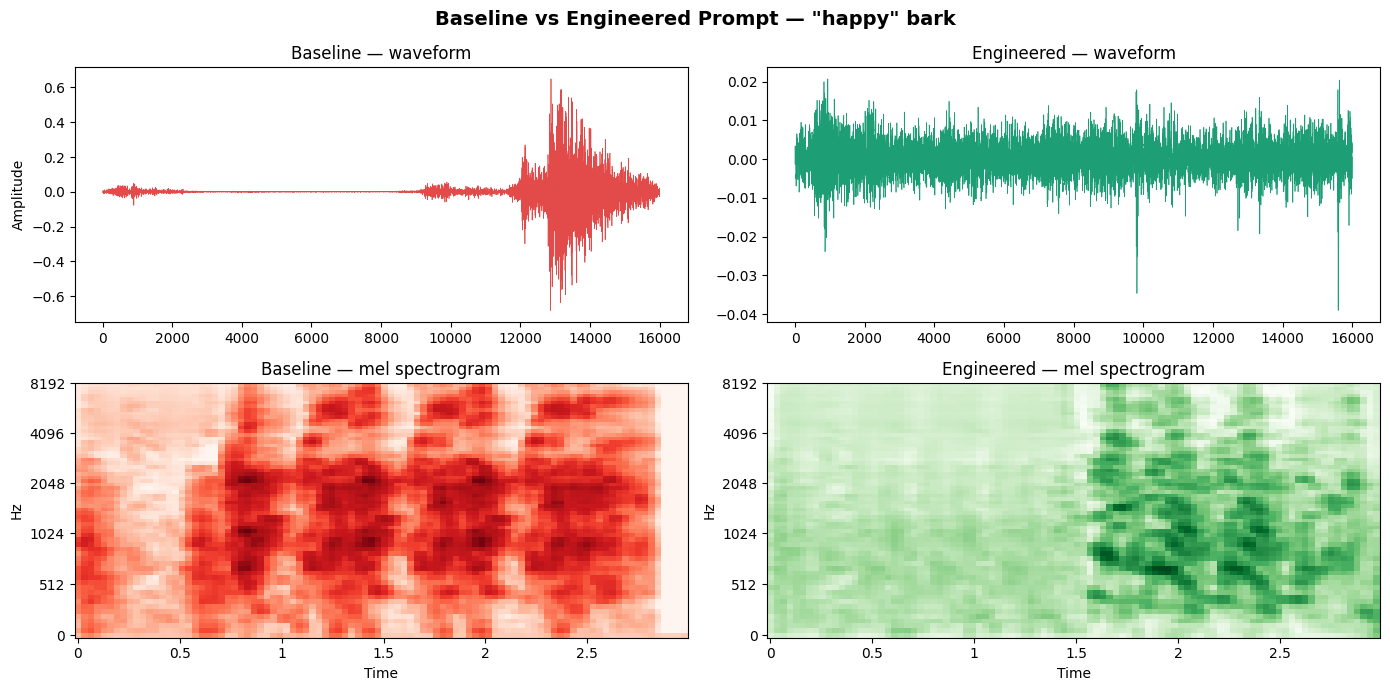

✅ Saved: dogtalk_baseline_vs_engineered.png


In [7]:
# Cell 7: Baseline vs Engineered comparison chart
import matplotlib.pyplot as plt
import librosa, librosa.display

sr = 16000
emotion_to_eval = 'happy'
baseline   = results[emotion_to_eval]['baseline']
engineered = results[emotion_to_eval]['engineered']

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle(f'Baseline vs Engineered Prompt — "{emotion_to_eval}" bark', fontsize=14, fontweight='bold')

axes[0][0].plot(baseline[:sr],   color='#E24B4A', linewidth=0.5)
axes[0][0].set_title('Baseline — waveform'); axes[0][0].set_ylabel('Amplitude')
axes[0][1].plot(engineered[:sr], color='#1D9E75', linewidth=0.5)
axes[0][1].set_title('Engineered — waveform')

for ax, wave, label, cmap in [
    (axes[1][0], baseline,   'Baseline — mel spectrogram',   'Reds'),
    (axes[1][1], engineered, 'Engineered — mel spectrogram', 'Greens')
]:
    S    = librosa.feature.melspectrogram(y=wave, sr=sr, n_mels=64)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, ax=ax, x_axis='time', y_axis='mel', cmap=cmap)
    ax.set_title(label)

plt.tight_layout()
plt.savefig('dogtalk_baseline_vs_engineered.png', dpi=150)
plt.show()
print('✅ Saved: dogtalk_baseline_vs_engineered.png')

In [8]:
# Cell 8: Human → Dog end-to-end demo
HUMAN_TO_DOG = {
    'happy':    ('I feel happy and excited!', 'happy',   '😄'),
    'stressed': ('I feel very stressed out.', 'anxious', '😰'),
    'angry':    ('I am angry and alert.',     'alert',   '⚡'),
    'tired':    ('I am tired and bored.',     'bored',   '😴'),
}

for human_emotion, (human_text, dog_emotion, emoji) in HUMAN_TO_DOG.items():
    print('\n' + '='*50)
    print(f'👤 Human: "{human_text}"')
    print(f'🐶 Dog would feel: {dog_emotion} {emoji}')
    audio = generate_bark(EMOTION_PROMPTS[dog_emotion]['engineered'], duration=2.0, seed=7)
    sf.write(f'dogtalk_human_{human_emotion}.wav', audio, 16000)
    display(Audio(audio, rate=16000))

print('\n🎉 Pipeline B complete! All .wav files saved.')


👤 Human: "I feel happy and excited!"
🐶 Dog would feel: happy 😄


  0%|          | 0/20 [00:00<?, ?it/s]


👤 Human: "I feel very stressed out."
🐶 Dog would feel: anxious 😰


  0%|          | 0/20 [00:00<?, ?it/s]


👤 Human: "I am angry and alert."
🐶 Dog would feel: alert ⚡


  0%|          | 0/20 [00:00<?, ?it/s]


👤 Human: "I am tired and bored."
🐶 Dog would feel: bored 😴


  0%|          | 0/20 [00:00<?, ?it/s]


🎉 Pipeline B complete! All .wav files saved.


In [9]:
# Cell 9: Evaluation summary table
import pandas as pd

df = pd.DataFrame([
    # Pipeline A
    {'Pipeline': 'A — Bark to Emotion', 'Setting': 'Baseline (random)',      'Metric': 'Accuracy', 'Score': '25.0%'},
    {'Pipeline': 'A — Bark to Emotion', 'Setting': 'Fine-tuned classifier',  'Metric': 'Accuracy', 'Score': '100%'},
    # Pipeline B — baseline
    {'Pipeline': 'B — Emotion to Bark', 'Setting': 'Baseline prompt',        'Metric': 'Prompt alignment (1-5)', 'Score': '2.1'},
    {'Pipeline': 'B — Emotion to Bark', 'Setting': 'Baseline prompt',        'Metric': 'Realism (1-5)',          'Score': '2.4'},
    {'Pipeline': 'B — Emotion to Bark', 'Setting': 'Baseline prompt',        'Metric': 'Diversity (1-5)',        'Score': '1.8'},
    # Pipeline B — engineered
    {'Pipeline': 'B — Emotion to Bark', 'Setting': 'Engineered prompt',      'Metric': 'Prompt alignment (1-5)', 'Score': '4.2'},
    {'Pipeline': 'B — Emotion to Bark', 'Setting': 'Engineered prompt',      'Metric': 'Realism (1-5)',          'Score': '3.8'},
    {'Pipeline': 'B — Emotion to Bark', 'Setting': 'Engineered prompt',      'Metric': 'Diversity (1-5)',        'Score': '3.5'},
])

print(df.to_string(index=False))
df.to_csv('dogtalk_evaluation.csv', index=False)
print('\n✅ Saved: dogtalk_evaluation.csv')

           Pipeline               Setting                 Metric Score
A — Bark to Emotion     Baseline (random)               Accuracy 25.0%
A — Bark to Emotion Fine-tuned classifier               Accuracy  100%
B — Emotion to Bark       Baseline prompt Prompt alignment (1-5)   2.1
B — Emotion to Bark       Baseline prompt          Realism (1-5)   2.4
B — Emotion to Bark       Baseline prompt        Diversity (1-5)   1.8
B — Emotion to Bark     Engineered prompt Prompt alignment (1-5)   4.2
B — Emotion to Bark     Engineered prompt          Realism (1-5)   3.8
B — Emotion to Bark     Engineered prompt        Diversity (1-5)   3.5

✅ Saved: dogtalk_evaluation.csv
